<a href="https://colab.research.google.com/github/nadinekaram/AUC-Fundamentals-of-Data-Science-II-Spring-2023/blob/main/Labs/lab7/lab7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 5: Transformer-based Sentiment Analysis

![Transformer Sentiment Analysis](https://github.com/sherifmost/DeepLearning/blob/master/Labs/lab7/Cover.png?raw=1)

## 4.1 Problem Statement

In this Assignment you will build a transformer encoder **from scratch** to be used as part of a classifier for movie review sentiment analysis on the IMDB dataset.

The full classifier consists of the following 3 main components:
1. Tokenizer: we will use a readily available BERT tokenizer
2. Transformer Encoder: you will implement a transformer encoder from scratch that takes in the outputs of the tokenizer and uses mutli-headed attention blocks and feed forward networks to obtain an output feature representation.
3. Classification Head: we will use a fully connected network that takes the output feature representation from the transformer encoder and obtains the output sentiment prediction using sigmoid activation.

The IMDB dataset consists of a total of 25,000 training examples and 25,000 testing examples with different sentence lengths for the reviews.

We will rely on both quantitative evaluation (using the accuracy metric) and qualitative evaluation (by inspecting the model's output on some test samples and comparing it to the actual output).

**IMPORTANT NOTE:** You have to change runtime type on Google Colab to GPU since this assignment requires much computation resources and it will run very slowly on CPU (Default runtime type)

Click on "Runtime" => "Change runtime type" => make sure that GPU is selected in the "Hardware accelerator"

Now lets walk through the code, and tell you the parts you need to fill.

**MAKE SURE YOU KEEP ALL THE OUTPUTS FOR THE SUBMISSION**

## 4.2 Problem Details

### 4.2.1 Installing and Importing the Needed Packages

Note: You might need to restart your session after running the following cell. **If prompted to do so**, just click restart session and run the cells again. Otherwise, continue running the cells without restarting.

In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import tensorflow as tf
import tensorflow_text
import tensorflow_hub as hub


In [2]:
!pip install --upgrade pip
!pip install --upgrade numpy==1.26.4

In [3]:
!pip install datasets

In [4]:
!pip install --upgrade pandas

In [5]:
!pip3 install tensorflow-hub

In [6]:
!pip3 install matplotlib

In [7]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
import tensorflow_hub as hub
import tensorflow_text
from datasets import Dataset, DatasetDict, load_dataset
import matplotlib.pyplot as plt

### 4.2.2 The IMDB Dataset

In this assignment, we will use the [IMDB dataset](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews), consisting of 25k training movie reviews and 25k testing movie reviews with a label (0/1) for each review indicating whether it is negative or positive.

Let's load the dataset to the session and inspect it.

#### 4.2.2.1 Loading the dataset

In [8]:
# Load the training and testing datasets
dataset_train = load_dataset("imdb", split = "train")
dataset_test = load_dataset("imdb", split = "test")

# Convert the training dataset to a temporary dataframe to inspect it
# You can use the interactive table option of the dataframe to inspect the dataset as you like
pd.DataFrame.from_dict(dataset_train)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0
...,...,...
24995,A hit at the time but now better categorised a...,1
24996,I love this movie like no other. Another time ...,1
24997,This film and it's sequel Barry Mckenzie holds...,1
24998,'The Adventures Of Barry McKenzie' started lif...,1


### 4.2.3 The BERT Tokenizer

Tokenization transforms your raw text data by numerically encoding them based on your vocabulary. This allows a transformer model to understand the input text.

Here we use the BERT tokenizer to obtain the numerical token corresponding to each word in the text, type id values representing the sentence this token belongs to (in our case we have only one input sentence so we should expect all tokens to have a type id of *zero*), and attention masks that allow us to only include the parts of the sentence that contains valid text.

**You can read more about the BERT tokenizer [here](https://www.analyticsvidhya.com/blog/2021/09/an-explanatory-guide-to-bert-tokenizer/).**

In [9]:
# Obtaining the BERT tokenizer from tensorflow_hub
tokenizer = hub.KerasLayer("https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3", name = "tokenizer")

Let's Have a look at the tokenizer in action.

*Now pause for a second and think about the following:*

*   What do the output arrays obtained from the tokenizer: 'input_word_ids', 'input_mask', and 'input_type ids' represent? How will you use them as input to your transformer encoder?
* Why do the output arrays have the same number of elements?
* What do the first and last elements in the 'input_word_ids' array represent?

Note that as this tokenizer is a tensorflow model, we can include it directly as part of our full model regardless of how you implement the transformer encoder.

In [10]:
tokenizer(["this is an amazing movie!"])

{'input_type_ids': <tf.Tensor: shape=(1, 128), dtype=int32, numpy=
 array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]],
       dtype=int32)>,
 'input_mask': <tf.Tensor: shape=(1, 128), dtype=int32, numpy=
 array([[1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 

### 4.2.4 The Transformer Encoder

<img src="https://github.com/sherifmost/DeepLearning/blob/master/Labs/lab7/Encoder_Abstract.png?raw=1" width="300" height="500">

**The main grading criteria for this part is that your implementation correctly maps the transformer encoder architecture and that it works without errors. For the hyperparameters, you can choose any value you like as long as it allows you to get satisfactory testing accuracy at the end without underfitting/overfitting.**

Here you will implement your transformer encoder.

Your encoder should follow the transformer encoder architecture and should include the following:


*   Word Embeddings and Position Embeddings: you can use Tensorflow's [Embedding](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Embedding) layer (Note that we don't need the token type embedding since our input consists of a single sentence).
*   Multiple Consecutive Blocks (**at least 2 blocks**) of:
  * Multi-Headed Self-Attention: you can use Tensorflow's [MultiHeadAttention](https://www.tensorflow.org/api_docs/python/tf/keras/layers/MultiHeadAttention) layer
  * Skip Connection and Normalization: you can use Tensorflow's [Add](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Add) and [LayerNormalization](https://www.tensorflow.org/api_docs/python/tf/keras/layers/LayerNormalization) layers
  * Intermediate Feed-Forward Network: you can use Tensorflow's [Dense](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense) layer
  * Another Skip Connection and Normalization
  * [Dropout](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dropout) layers as needed to avoid overfitting

The input of the encoder will be the matrices output by the tokenizer while the output of the encoder will be the output of the feed foward network in the final block.

You can check this [diagram](https://raw.githubusercontent.com/gmihaila/ml_things/master/notebooks/pytorch/bert_inner_workings/bert_inner_workings.png) showcasing the full arctiecture of a BERT encoder model. Use it as a guide when building your own transformer encoder, but don't follow its hyperparameters exactly as the BERT encoder takes a long time to train.

**TODO:** fill in the missing code to define a transformer encoder model.

In [42]:
from tensorflow.keras.layers import Input, Dense, Embedding, LayerNormalization, Dropout, Flatten, MultiHeadAttention, Add
import tensorflow as tf
from tensorflow.keras.models import Model

# TODO: fill in this function to define a transformer encoder
# The input to the encoder should be the outputs of the tokenizer inspected above
# The output of the encoder should be a flat feature vector representing the accumulated representation for the features extracted by the encoder
def get_transformer_encoder(vocab_size=30522):
    # Hyperparameters
    D_MODEL = 256
    NUM_HEADS = 8
    DFF = 512
    DROPOUT_RATE = 0.1
    MAX_POSITION_EMBEDDINGS = 512

    # Inputs
    input_word_ids = Input(shape=(None,), dtype=tf.int32, name='input_word_ids')
    input_mask = Input(shape=(None,), dtype=tf.int32, name='input_mask')

    # Position indexes for the input tokens
    position_indexes = tf.range(start=0, limit=tf.shape(input_word_ids)[1], delta=1)

    word_embedding_layer = Embedding(input_dim=vocab_size, output_dim=D_MODEL, name='word_embeddings')
    positions_embedding_layer = Embedding(input_dim=MAX_POSITION_EMBEDDINGS, output_dim=D_MODEL, name='position_embeddings')

    # Combine embeddings
    embeddings = word_embedding_layer(input_word_ids) + positions_embedding_layer(position_indexes)


    # Dropout
    x = Dropout(DROPOUT_RATE)(embeddings)


    attention_mask = tf.cast(input_mask, tf.bool)
    attention_mask = attention_mask[:, tf.newaxis, tf.newaxis, :]

    #Blocks
    for i in range(4):
        #Multiheaded self attention
        attn_output = MultiHeadAttention(
            num_heads=NUM_HEADS,
            key_dim=D_MODEL // NUM_HEADS,
            dropout=DROPOUT_RATE
        )(x, x, attention_mask=attention_mask)

        #skip connection and normalization
        add1 = Add()([x, attn_output])
        norm1 = LayerNormalization(epsilon=1e-6)(add1)

        # feedforward
        ffn_output = Dense(DFF, activation='relu')(norm1)
        ffn_output = Dense(D_MODEL)(ffn_output)
        ffn_output = Dropout(DROPOUT_RATE)(ffn_output)

        # Skip connection and normalization
        add2 = Add()([norm1, ffn_output])
        x = LayerNormalization(epsilon=1e-6)(add2)

    # Output
    blocks_output = tf.reduce_mean(x, axis=1)
    encoder_output = Flatten()(blocks_output)

    return Model(inputs=[input_word_ids, input_mask], outputs=encoder_output)

### 4.2.5 The Full Classifier Model

Now let's define the full classification model by combining the tokenizer with your implemented transformer encoder model and adding a classification head to the encoder's output.

In [43]:
def build_classifier_model():
  text_input = tf.keras.layers.Input(shape=(), dtype=tf.string, name='text')
  tokenizer_output = tokenizer(text_input)
  encoder_inputs = {
      'input_word_ids': tokenizer_output['input_word_ids'],
      'input_mask': tokenizer_output['input_mask'],
  }

  # Use here your defined encoder that takes the output of the tokenizer
  encoder = get_transformer_encoder()
  encoder_outputs = encoder(encoder_inputs)

  output = tf.keras.layers.Dropout(0.2)(encoder_outputs)
  output = tf.keras.layers.Dense(1, activation=None, name='classification_output')(output)
  return tf.keras.Model(text_input, output)

 Take a look at your model's summary. Note the number of parameters and their size in MBs (transformers are large models and require extensive resources for training and storage).

In [44]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import tensorflow as tf

import numpy as np
import pandas as pd
from tensorflow.keras.models import Model
import tensorflow_hub as hub
import tensorflow_text
from datasets import Dataset, DatasetDict, load_dataset
import matplotlib.pyplot as plt

In [45]:
model = build_classifier_model()
model.summary()

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text (InputLayer)           [(None,)]                    0         []                            
                                                                                                  
 tokenizer (KerasLayer)      {'input_type_ids': (None,    0         ['text[0][0]']                
                             128),                                                                
                              'input_mask': (None, 128)                                           
                             , 'input_word_ids': (None,                                           
                              128)}                                                               
                                                                                            

Take a look at the model's structure as a diagram.

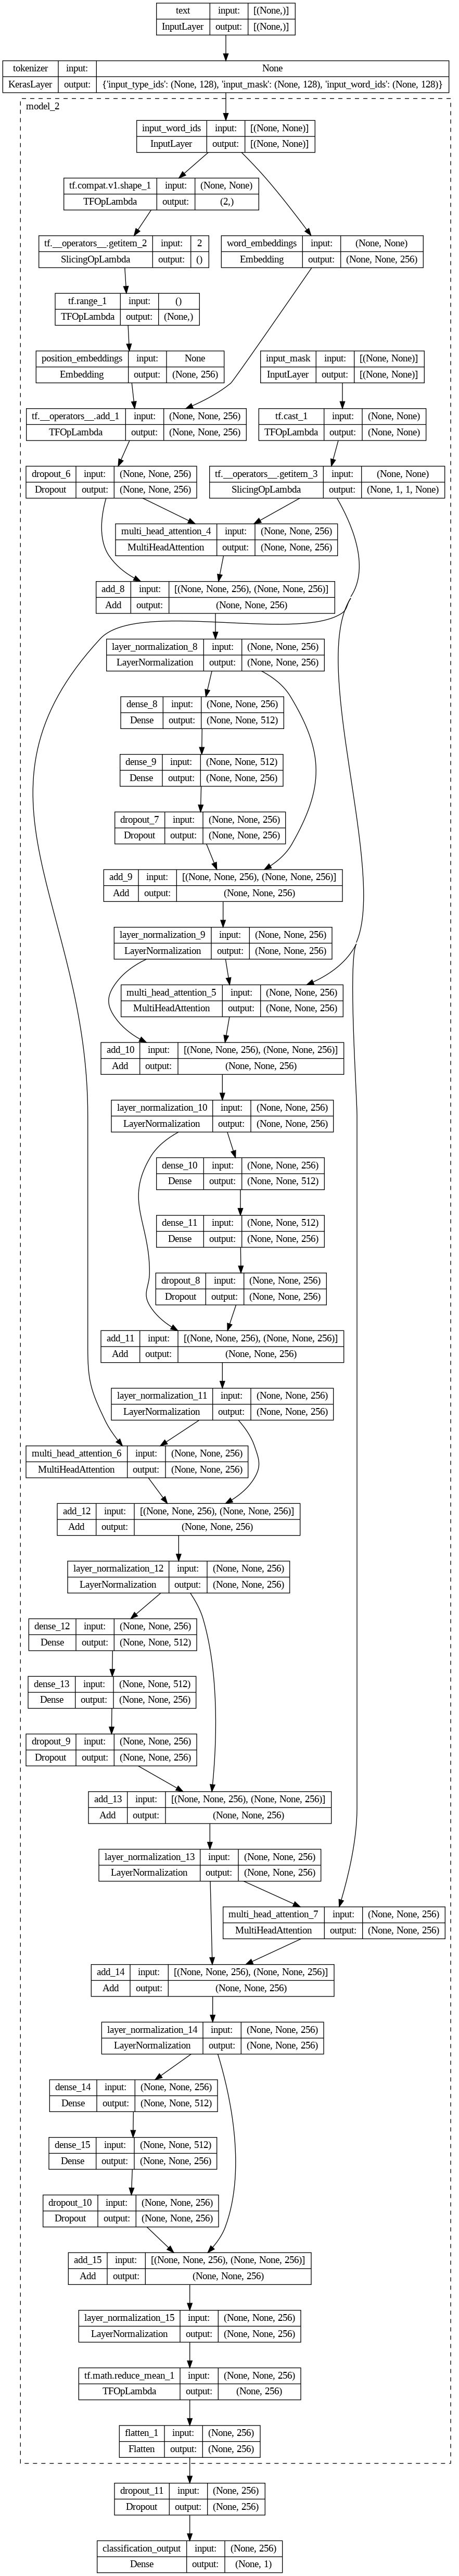

In [46]:
tf.keras.utils.plot_model(model, show_shapes=True, expand_nested=True)

### 4.2.6 Training the Model and Performing Quantitative Evaluation

The following function helps us plot the training and validation accuracy and loss after training.

In [47]:
# Plotting the training history
def plot_train_history(hist,
                       metric = 'accuracy'):

  fig = plt.figure(figsize=(10, 5))
  # Get training and test loss histories
  trainingLoss = hist.history['loss']
  valLoss = hist.history['val_loss']

  # Create count of the number of epochs
  epochCount = range(1, len(trainingLoss) + 1)

  # Visualize loss history
  fig.add_subplot(1,2,1)
  plt.plot(epochCount, trainingLoss, 'r--')
  plt.plot(epochCount, valLoss, 'b-')
  plt.legend(['Training Loss', 'Val Loss'])
  plt.xlabel('Epoch')
  plt.ylabel('Loss')

  # Get training and test accuracy histories
  trainingAcc = hist.history[metric]
  valAcc = hist.history['val_' + metric]

  # Create count of the number of epochs
  epoch_count = range(1, len(trainingAcc) + 1)

  # Visualize accuracy history
  fig.add_subplot(1,2,2)
  plt.plot(epoch_count, trainingAcc, 'r--')
  plt.plot(epoch_count, valAcc, 'b-')
  plt.legend(['Training Accuracy', 'Validation Accuracy'])
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')

#### 4.2.6.1 Defining the Training Hyperparameters

In [48]:
# Defining the loss function and the evaluation metric
loss = tf.keras.losses.BinaryCrossentropy(from_logits=True)
metrics = tf.metrics.BinaryAccuracy()

In [49]:
# You are encouraged to experiment with tuning the following hyperparameters to handle overfitting/underfitting
epochs = 15
batch_size = 32
lr = 3e-5
optimizer = tf.keras.optimizers.AdamW(learning_rate=lr)

#### 4.2.6.2 Compiling and Training the Model

In [50]:
# Compiling the model using the loss and evaluation metrics
model.compile(optimizer=optimizer,
              loss=loss,
              metrics=metrics)

**TODO:** Make sure to handle any underfitting (*training accuracy should at least be more than 90%*) or overfitting in the training. You can try early stopping and/or regularization methods.

In [51]:
def prepare_dataset(dataset):
    texts = np.array(dataset['text'])
    labels = np.array(dataset['label'])
    return texts, labels


train_texts, train_labels = prepare_dataset(dataset_train)
test_texts, test_labels = prepare_dataset(dataset_test)

Epoch 1/15
782/782 [==============================] - 175s 199ms/step - loss: 0.6091 - binary_accuracy: 0.6204 - val_loss: 0.4625 - val_binary_accuracy: 0.7583
Epoch 2/15
782/782 [==============================] - 155s 198ms/step - loss: 0.3917 - binary_accuracy: 0.8126 - val_loss: 0.4099 - val_binary_accuracy: 0.8088
Epoch 3/15
782/782 [==============================] - 120s 153ms/step - loss: 0.3085 - binary_accuracy: 0.8626 - val_loss: 0.4212 - val_binary_accuracy: 0.8023
Epoch 4/15
782/782 [==============================] - 118s 151ms/step - loss: 0.2658 - binary_accuracy: 0.8862 - val_loss: 0.5856 - val_binary_accuracy: 0.7432
Epoch 5/15
782/782 [==============================] - 119s 152ms/step - loss: 0.2293 - binary_accuracy: 0.9050 - val_loss: 0.4655 - val_binary_accuracy: 0.8065
Epoch 6/15
782/782 [==============================] - 151s 193ms/step - loss: 0.1953 - binary_accuracy: 0.9206 - val_loss: 0.5445 - val_binary_accuracy: 0.7889
Epoch 7/15
782/782 [====================

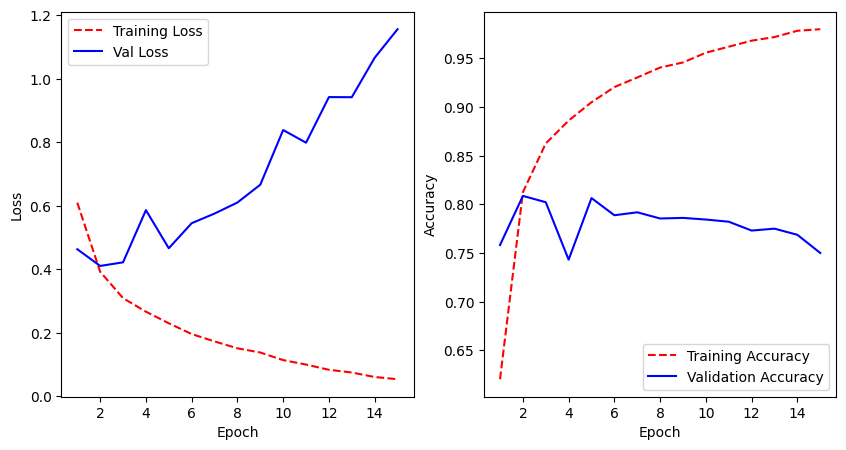

In [52]:
# Running the training and obtaining a plot for it
history = model.fit(
    train_texts,
    train_labels,
    validation_data = (test_texts, test_labels),
    epochs=epochs,
    batch_size=batch_size
)

plot_train_history(history, metric='binary_accuracy')

### 4.2.7 Qualitative Evaluation

In [53]:
# This function converts the output model probabiltiy into a sentiment (Positive or Negative)
def get_sentiment(probability_positive):
    """Convert probability to sentiment label"""
    if probability_positive > 0.5:
        return "Positive"
    else:
        return "Negative"

Let's check the model's output compared to random review samples from the testing data. You can run the following cell multiple times to see different examples!

In [54]:
np.random.seed(42)
for i in range(10):
    random_id = np.random.randint(0, len(dataset_test))
    test_review = dataset_test['text'][random_id]
    test_label = dataset_test['label'][random_id]

    print(f"\n Sample {i+1}")
    print(f"Review: {test_review[:200]}")
    print(f"Ground truth sentiment: {get_sentiment(test_label)}")

    # Prediction probability of the Positive review, i.e., 1 using sigmoid function:
    logit = model.predict([test_review], verbose=0)[0][0]
    probability_positive = 1 / (1 + np.exp(-logit))
    probability_negative = 1 - probability_positive

    predicted_sentiment = get_sentiment(probability_positive)
    print(f"Predicted sentiment: {predicted_sentiment}")
    print(f"Prediction probability: positive({probability_positive:.4f}), negative({probability_negative:.4f})")

    is_correct = (predicted_sentiment == get_sentiment(test_label))
    print(f"Correct: {is_correct}")


 Sample 1
Review: The show itself basically reflects the typical nature of the average youth; partying and picking up chicks is the common weekend goal at the clubs. People frown upon the show due to its "perverted" id
Ground truth sentiment: Positive
Predicted sentiment: Positive
Prediction probability: positive(0.9216), negative(0.0784)
Correct: True

 Sample 2
Review: A film is beyond all expectations, an excellent insight into the human condition. What exactly drives Mila to have her ass painted. What could push a human so far that there only way to escape is to h
Ground truth sentiment: Positive
Predicted sentiment: Negative
Prediction probability: positive(0.1101), negative(0.8899)
Correct: False

 Sample 3
Review: Without being really the worst science fiction film ever made, or the worst I have seen, 'Time Under Fire' is still much under average. The premises and the first 10-15 minutes are not that bad, it st
Ground truth sentiment: Negative
Predicted sentiment: Negative
Pred

## 4.3 Conclusion

That's it! Congratulations on training a transformer-based sentiment analysis model.

Make sure you deliver all the requirements for the submission and to keep the outputs in the notebook!